In [1]:
import os, sys
import numpy as np
import torch

sys.path.append(os.path.abspath("."))
from src.train import train_dgd
from src.model import DGDModel

## Toy mixed-types data

In [2]:
rng = np.random.default_rng(42)

n_samples = 1200
n_clusters = 3
cluster_ids = rng.integers(low=0, high=n_clusters, size=n_samples)

# Feature group sizes (you can shrink if training is slow)
n_poiss = 4         # Poisson counts
n_nb    = 4         # Negative Binomial counts (overdispersed)
n_mult  = 6         # Multinomial count vector (composition)
n_gauss = 3         # Gaussian continuous
n_beta  = 3         # Beta proportions in (0,1)
n_bern  = 4         # Bernoulli binary

# Allocate blocks
X_poiss = np.zeros((n_samples, n_poiss), dtype=float)
X_nb    = np.zeros((n_samples, n_nb),    dtype=float)
X_mult  = np.zeros((n_samples, n_mult),  dtype=float)
X_gauss = np.zeros((n_samples, n_gauss), dtype=float)
X_beta  = np.zeros((n_samples, n_beta),  dtype=float)
X_bern  = np.zeros((n_samples, n_bern),  dtype=float)

# -------- cluster-specific parameters --------

# Poisson rates (K x n_poiss)
poiss_rates = np.array([
    [1.0, 2.0,  3.0, 1.5],
    [6.0, 1.0,  2.0, 0.5],
    [2.0, 7.0,  1.0, 3.5],
])

# Negative Binomial parameters: mean mu (K x n_nb) and dispersion r (K x n_nb)
# (higher r -> less overdispersion; lower r -> more overdispersion)
nb_mu = np.array([
    [2.0, 3.0, 1.0, 4.0],
    [8.0, 1.0, 2.0, 1.0],
    [3.0, 7.0, 1.0, 2.0],
])
nb_r = np.array([
    [2.0, 2.0, 1.5, 3.0],
    [1.0, 2.5, 2.0, 1.0],
    [3.0, 1.2, 2.0, 2.5],
])

# Multinomial: probabilities over n_mult categories + totals N
mult_probs = np.array([
    [0.50, 0.10, 0.10, 0.10, 0.10, 0.10],
    [0.10, 0.50, 0.10, 0.10, 0.10, 0.10],
    [0.10, 0.10, 0.10, 0.10, 0.10, 0.50],
])
mult_total = np.array([30, 50, 40])  # total counts per cluster (can vary)

# Gaussian means + shared std
gauss_means = np.array([
    [0.0,  0.0,  0.0],
    [2.0, -1.0,  1.5],
    [-2.0, 1.0, -1.5],
])
gauss_std = 0.5

# Beta: mean in (0,1) and concentration kappa (larger -> less variance)
beta_mean = np.array([
    [0.2, 0.7, 0.4],
    [0.8, 0.3, 0.6],
    [0.5, 0.5, 0.2],
])
beta_kappa = np.array([
    [12.0, 10.0, 8.0],
    [10.0, 12.0, 9.0],
    [8.0,  8.0, 12.0],
])

# Bernoulli probabilities
bern_probs = np.array([
    [0.1, 0.2, 0.8, 0.9],
    [0.7, 0.3, 0.1, 0.2],
    [0.4, 0.6, 0.4, 0.6],
])

# -------- sampling helpers --------

def sample_nb(mu, r, rng):
    """
    Sample Negative Binomial using Gamma-Poisson mixture:
      lambda ~ Gamma(shape=r, scale=mu/r)
      y ~ Poisson(lambda)
    """
    lam = rng.gamma(shape=r, scale=mu / r)
    return rng.poisson(lam=lam)

def sample_beta_from_mean_kappa(m, k, rng):
    a = m * k
    b = (1.0 - m) * k
    return rng.beta(a, b)

# -------- generate dataset --------

for i, k in enumerate(cluster_ids):
    # Poisson block
    X_poiss[i] = rng.poisson(lam=poiss_rates[k], size=n_poiss)

    # NB block
    X_nb[i] = np.array([sample_nb(nb_mu[k, j], nb_r[k, j], rng) for j in range(n_nb)], dtype=float)

    # Multinomial block (vector with total counts)
    N = mult_total[k]
    X_mult[i] = rng.multinomial(n=N, pvals=mult_probs[k]).astype(float)

    # Gaussian block
    X_gauss[i] = rng.normal(loc=gauss_means[k], scale=gauss_std, size=n_gauss)

    # Beta block (strictly in (0,1))
    X_beta[i] = np.array([sample_beta_from_mean_kappa(beta_mean[k, j], beta_kappa[k, j], rng)
                          for j in range(n_beta)], dtype=float)

    # Bernoulli block (0/1)
    X_bern[i] = rng.binomial(n=1, p=bern_probs[k], size=n_bern).astype(float)

# Concatenate all features
X = np.concatenate([X_poiss, X_nb, X_mult, X_gauss, X_beta, X_bern], axis=1)
n_features = X.shape[1]

print("X shape:", X.shape)
print("Example row:", X[0])

X shape: (1200, 24)
Example row: [ 1.          5.          6.          2.          1.          6.
  1.          5.         13.          4.          5.          0.
  4.          4.         -0.30983297  0.23556815 -0.26672617  0.19177786
  0.85096145  0.36784379  0.          0.          1.          1.        ]


## Model setting

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, cluster_ids, test_size=0.2, random_state=42, stratify=cluster_ids
)

X_train.shape, X_test.shape

((960, 24), (240, 24))

In [4]:
start = 0
poiss_cols = list(range(start, start + n_poiss)); start += n_poiss
nb_cols    = list(range(start, start + n_nb));    start += n_nb
mult_cols  = list(range(start, start + n_mult));  start += n_mult
gauss_cols = list(range(start, start + n_gauss)); start += n_gauss
beta_cols  = list(range(start, start + n_beta));  start += n_beta
bern_cols  = list(range(start, start + n_bern));  start += n_bern

print("Poisson cols:    ", poiss_cols)
print("NB cols:         ", nb_cols)
print("Multinomial cols:", mult_cols)
print("Gaussian cols:   ", gauss_cols)
print("Beta cols:       ", beta_cols)
print("Bernoulli cols:  ", bern_cols)
print("Total features check:", start, "==", n_features)


Poisson cols:     [0, 1, 2, 3]
NB cols:          [4, 5, 6, 7]
Multinomial cols: [8, 9, 10, 11, 12, 13]
Gaussian cols:    [14, 15, 16]
Beta cols:        [17, 18, 19]
Bernoulli cols:   [20, 21, 22, 23]
Total features check: 24 == 24


In [5]:
output_module = "composite"
output_module_options = {
    "heads": [
        {"module": "poisson",     "cols": poiss_cols},
        {"module": "nb",          "cols": nb_cols, "options": {"shared_dispersion": False, "learn_dispersion": True, "log_r_init": 0.0}},
        {"module": "multinomial", "cols": mult_cols},
        {"module": "gaussian",    "cols": gauss_cols, "options": {"train_log_var": True, "log_var_init": 0.0}},
        {"module": "beta",        "cols": beta_cols,  "options": {"eps": 1e-5, "min_concentration": 2.0}},
        {"module": "bernoulli",   "cols": bern_cols},
    ]
}

## Training

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model, history = train_dgd(
    X_train=X_train,
    X_test=X_test,
    latent_dim=2,
    n_components=3,
    hidden_dims=(16, 16),
    output_module=output_module,
    output_module_options=output_module_options,
    weights_prior_options={"alpha": 0.3},
    batch_size=64,
    lr_prior=1e-2,
    lr_decoder=5e-3,
    lr_rep_train=1e-2,
    lr_rep_test=1e-2,
    n_epochs=150,
    # IMPORTANT: keep raw values for these likelihoods
    log_transform=False,
    standardize=False,
    device=device,
)


Using device: cuda
Epoch 001 | train loss=98.9643 (recon=94.6581, prior=4.3062 [z=4.0009, params=0.3054]) | test loss=95.1363 (recon=91.1394, prior=3.9968 [z=3.6706, params=0.3263])
Epoch 002 | train loss=93.4177 (recon=89.7562, prior=3.6615 [z=3.3547, params=0.3068]) | test loss=90.7727 (recon=87.3013, prior=3.4714 [z=3.1428, params=0.3286])
Epoch 003 | train loss=90.1698 (recon=86.9755, prior=3.1943 [z=2.8847, params=0.3096]) | test loss=88.8325 (recon=85.7554, prior=3.0772 [z=2.7447, params=0.3325])
Epoch 004 | train loss=88.6457 (recon=85.8040, prior=2.8417 [z=2.5279, params=0.3138]) | test loss=87.9274 (recon=85.1584, prior=2.7690 [z=2.4316, params=0.3374])
Epoch 005 | train loss=87.7133 (recon=85.1392, prior=2.5741 [z=2.2553, params=0.3188]) | test loss=87.1788 (recon=84.6597, prior=2.5190 [z=2.1759, params=0.3431])
Epoch 006 | train loss=86.3117 (recon=83.9444, prior=2.3673 [z=2.0430, params=0.3243]) | test loss=86.0393 (recon=83.7296, prior=2.3098 [z=1.9606, params=0.3492])
Epo

In [7]:
model

DGDModel(
  (prior): GaussianMixturePrior(
    (means_prior_dist): SoftballPrior()
    (log_var_prior_dist): GaussianPrior()
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ReLU()
    )
    (out): CompositeOutput(
      (heads): ModuleList(
        (0): PoissonOutput(
          (rate_layer): Linear(in_features=16, out_features=4, bias=True)
        )
        (1): NegativeBinomialOutput(
          (mean_layer): Linear(in_features=16, out_features=4, bias=True)
        )
        (2): MultinomialOutput(
          (logits_layer): Linear(in_features=16, out_features=6, bias=True)
        )
        (3): GaussianOutput(
          (mean_layer): Linear(in_features=16, out_features=3, bias=True)
        )
        (4): BetaOutput(
          (mean_layer): Linear(in_features=16, out_features=3, bias=True)
          (conc_layer): Linear(in_features=

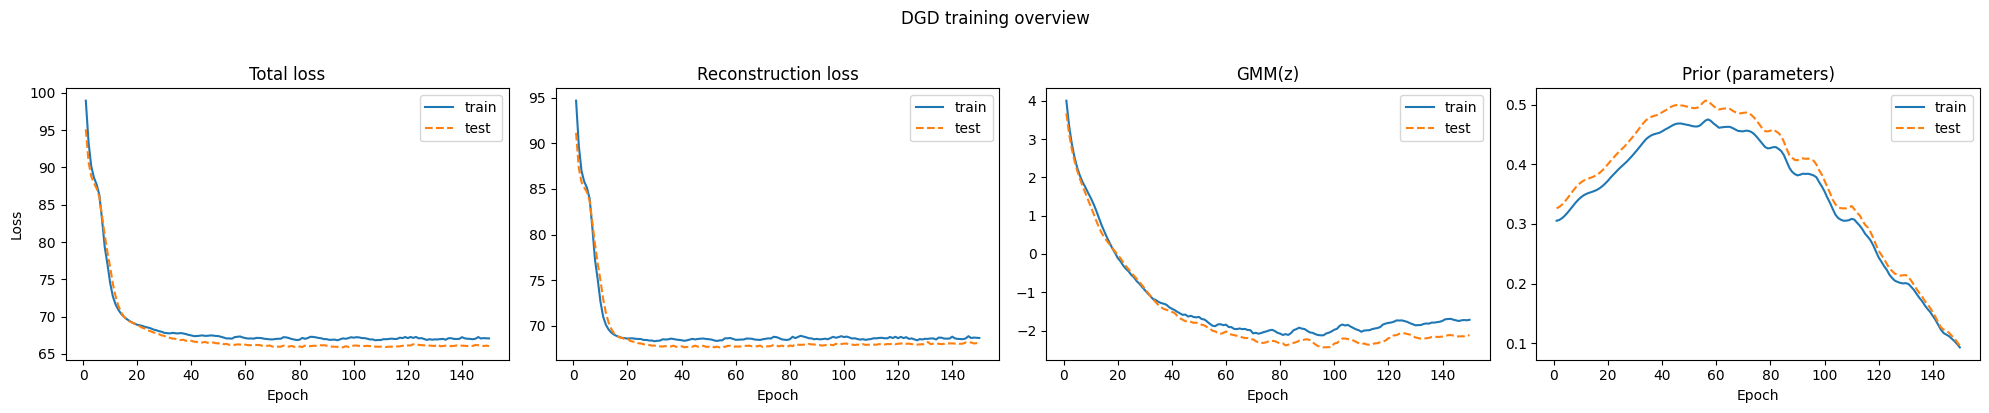

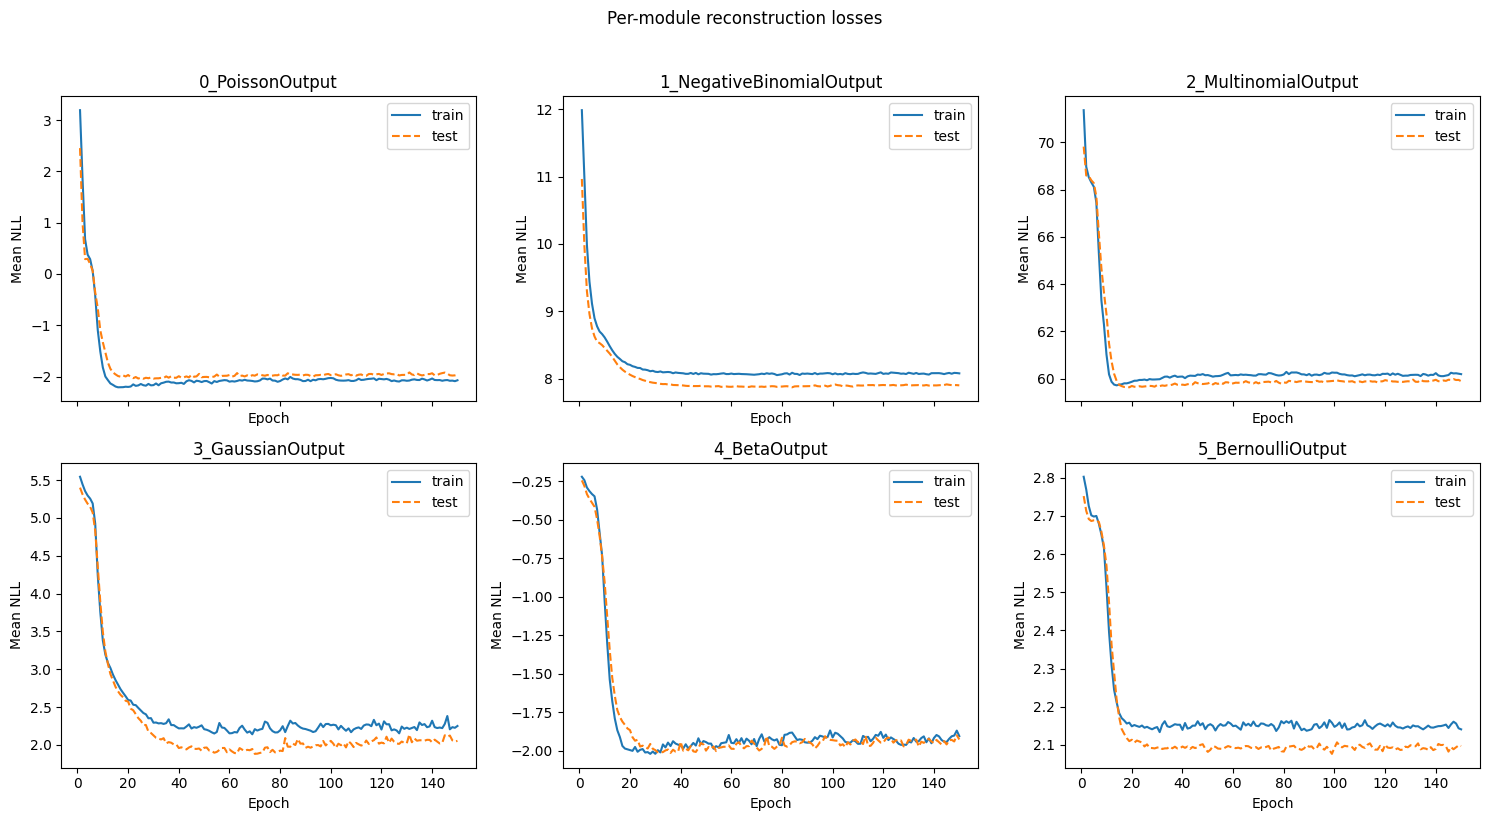

In [8]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(history["train_loss"]) + 1)

# =========================
# 1) Global losses (1 row, 3 subplots)
# =========================
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)

# --- total loss ---
ax = axes[0]
ax.plot(epochs, history["train_loss"], label="train")
ax.plot(epochs, history["test_loss"],  label="test", linestyle="--")
ax.set_title("Total loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# --- recon loss ---
ax = axes[1]
ax.plot(epochs, history["train_recon"], label="train")
ax.plot(epochs, history["test_recon"],  label="test", linestyle="--")
ax.set_title("Reconstruction loss")
ax.set_xlabel("Epoch")
ax.legend()

# --- prior (z under GMM) ---
ax = axes[2]
ax.plot(epochs, history["train_prior_z"], label="train")
ax.plot(epochs, history["test_prior_z"],  label="test", linestyle="--")
ax.set_title("GMM(z)")
ax.set_xlabel("Epoch")
ax.legend()

# --- prior (GMM parameters) ---
ax = axes[3]
ax.plot(epochs, history["train_prior_params"], label="train")
ax.plot(epochs, history["test_prior_params"],  label="test", linestyle="--")
ax.set_title("Prior (parameters)")
ax.set_xlabel("Epoch")
ax.legend()

fig.suptitle("DGD training overview", y=1.02)
fig.tight_layout()
plt.show()


# =========================
# 2) Per-module recon losses (automatic grid of subplots)
# =========================

# Collect all component names seen across epochs
all_names = set()
for d in history["train_recon_components"]:
    all_names.update(d.keys())
all_names = sorted(all_names)

if all_names:
    n_components = len(all_names)
    ncols = min(n_components, 3)
    nrows = int(np.ceil(n_components / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, all_names):
        train_vals = [d.get(name, float("nan")) for d in history["train_recon_components"]]
        test_vals  = [d.get(name, float("nan")) for d in history["test_recon_components"]]

        ax.plot(epochs, train_vals, label="train")
        ax.plot(epochs, test_vals,  label="test", linestyle="--")
        ax.set_title(name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Mean NLL")
        ax.legend()

    # Hide any unused axes (if grid is bigger than number of components)
    for ax in axes[len(all_names):]:
        ax.set_visible(False)

    fig.suptitle("Per-module reconstruction losses", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("No per-module recon components found in history.")

### Inspect latent

In [9]:
Z_train = model.rep_train.values.detach().cpu().numpy()
Z_test  = model.rep_test.values.detach().cpu().numpy()

Z_train.shape, Z_test.shape

((960, 2), (240, 2))

In [10]:
import umap

# Fit on train, transform both
umap_model = umap.UMAP(random_state=42)
Z_train_2d = umap_model.fit_transform(Z_train)
Z_test_2d  = umap_model.transform(Z_test)

/shared/crollo/GeneralDGD/generalDDG_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/shared/crollo/GeneralDGD/generalDDG_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


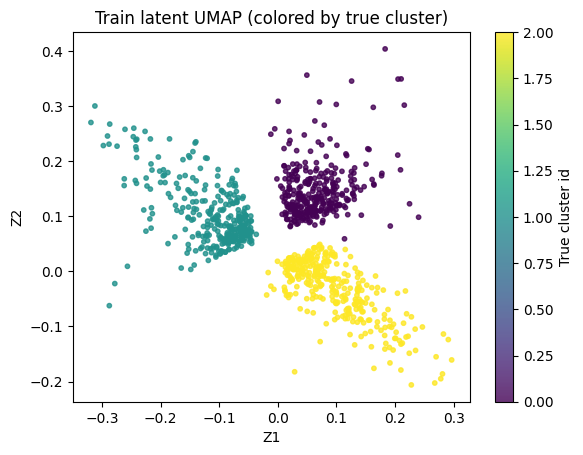

In [11]:
import matplotlib.pyplot as plt

plt.figure()
scatter = plt.scatter(Z_train[:, 0], Z_train[:, 1],
                      c=y_train, cmap="viridis", s=10, alpha=0.8)
plt.colorbar(scatter, label="True cluster id")
plt.title("Train latent UMAP (colored by true cluster)")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.show()


### Inspect GMM components

In [12]:
prior = model.prior

means = prior.means.detach().cpu().numpy()          # (K, latent_dim)
log_vars = prior.log_vars.detach().cpu().numpy()    # (K, latent_dim)
weights = prior.mixture_probs.detach().cpu().numpy() # (K,)

print("Mixture weights:", weights)
print("Component means:\n", means)


Mixture weights: [1.2869213e-11 5.7310615e-12 1.0000000e+00]
Component means:
 [[0.06323545 1.7522948 ]
 [0.6475151  0.09471956]
 [0.02332474 0.06611266]]


In [13]:
with torch.no_grad():
    Z_train_t = torch.tensor(Z_train, device=device, dtype=torch.float32)
    log_p_zk = prior.log_prob_components(Z_train_t)      # (N_train, K)
    log_pi = torch.log(prior.mixture_probs)              # (K,)
    log_post = log_p_zk + log_pi.unsqueeze(0)
    log_post = log_post - torch.logsumexp(log_post, dim=1, keepdim=True)
    gamma_train = torch.exp(log_post).cpu().numpy()      # (N_train, K)

gamma_train[:5]


array([[7.5418987e-14, 1.0063017e-13, 1.0000000e+00],
       [5.1770637e-14, 7.5818793e-14, 1.0000000e+00],
       [8.9871307e-14, 1.6803499e-13, 1.0000000e+00],
       [2.2420344e-13, 4.8902673e-13, 1.0000000e+00],
       [3.9401479e-14, 6.6120117e-14, 1.0000000e+00]], dtype=float32)

In [14]:
comp_assignments = gamma_train.argmax(axis=1)

In [15]:
model.eval()
rep_train = model.rep_train.to(device)

# pick a few samples
idx = np.random.choice(len(X_train), size=5, replace=False)
idx_t = torch.tensor(idx, device=device, dtype=torch.long)

with torch.no_grad():
    z_batch = rep_train(idx_t)
    out = model.decoder(z_batch)

    # handle composite / others
    if isinstance(out, (list, tuple)):
        out_params = out
    else:
        out_params = (out,)

# Now, depending on module, interpret outputs
print("Original rows:\n", X_train[idx])
print("\nDecoded parameters:")

from src.decoder import OUTPUT_MODULES  # just to know what heads are

# here we know it's composite: [poisson_out, gaussian_out, bernoulli_out]
poisson_rate, (gauss_mean, gauss_log_var), bern_logits = out_params[0], out_params[1], out_params[2]

print("Poisson rates (approx counts):\n", poisson_rate.cpu().numpy())
print("Gaussian means:\n", gauss_mean.cpu().numpy())
print("Bernoulli probs:\n", torch.sigmoid(bern_logits).cpu().numpy())


Original rows:
 [[10.          1.          3.          0.          3.          1.
   2.          0.          3.         32.          4.          4.
   2.          5.          1.46380302 -1.56242111  1.60032143  0.86440266
   0.18530061  0.69911869  1.          1.          0.          0.        ]
 [ 6.          8.          1.          4.          1.          8.
   1.          2.          6.          6.          1.          2.
   6.         19.         -2.85513449  1.5533227  -1.91736516  0.32459065
   0.74680825  0.26741996  0.          1.          0.          1.        ]
 [ 3.         10.          3.          3.          0.          5.
   2.          6.          4.          6.          3.          4.
   3.         20.         -2.03306257  2.00587893 -0.65486564  0.48343077
   0.40728957  0.30174229  0.          0.          0.          1.        ]
 [ 2.         11.          0.          4.          1.          5.
   0.          2.          3.          7.          3.          3.
  10.    